# 聚类分析

### 层次聚类法

```scipy.cluster.hierarchy```模块的层次聚类函数(cluster聚类，簇，hierarchy层次，等级)

1. ```distance.pdist ``` 

&emsp;&emsp;```B = pdist(A, metric='euclidean')``` 用 metric 指定的方法计算 $n \times p$ 矩阵 $\boldsymdf_np_ladf_np_ladf_np_labelelelol{A}$ (看作 $n$ 个 $p$ 维行向量，每行是一个对象的数据)中两两对象间的距离，metric可取下表中的特征字符串。  
&emsp;&emsp;返回值 B 是包含距离信息的长度为 $\frac{n·(n-1)}{2}$ (上三角或下三角的元素个数)的向量。可用 ```distance.squareform``` 函数将此向量转换为方阵（$(n-1, n-1)$）(对称矩阵)，这样可使矩阵中的 $(i, j)$ 元素对应原始数据中对象 $i$ 和 $j$ 间的距离。

**常用的 `metric` 取值及含义**

| 字符串         | 含义               |
| -------------- | ------------------ |
| `'euclidean'`  | 欧氏距离 (default)  |
| `'cityblock'`  | 绝对值距离         |
| `'minkowski'`  | Minkowski 距离     |
| `'chebychev'`  | Chebychev 距离     |
| `'mahalanobis'`| Mahalanobis 距离   |
|      其他      |      其他         |  

可使用下列代码查看metric的其他取值
 ```python
 >>>import scipy.cluster.hierarchy as sch
 >>>help(sch.distance.pdist)
```

2. `linkage`

&emsp;&emsp;`Z=linkage(B, 'method')` 使用由`'method'` 指定的算法计算生成聚类树，输入矩阵 B 维 pdist 函数输出的 $\frac{n·(n-1)}{2}$ 维距离行向量，`'method'` 可取下表的特征字符串值。

**'method' 取值及含义**

| 字符串      | 含义                          |
| ----------- | ----------------------------- |
| 'single'    | 最短距离 (default)             |
| 'average'   | 无权平均距离                  |
| 'centroid'  | 重心距离                      |
| 'complete'  | 最大距离                      |
| 'ward'      | 离差平方和方法 (Ward 方法)    |

&emsp;&emsp;输出 $\boldsymbol{Z}$ 为包含聚类树信息的 $(n-1) \times 4$ 矩阵。聚类树上的叶节点为原始数据集中的对象，其编号由 0 到 $n-1$，它们是单元素的类，级别更高的类都由它们生成。对应于 $\boldsymbol{Z}$ 中第 $j$ 行（第 $j$ 次）每个新生成的类，其索引为 $n+j$，其中 $n$ 为初始叶节点的数量。  

&emsp;&emsp;$\boldsymbol{Z}$ 的第 1 列和第 2 列，即 $\boldsymbol{Z}[:, :2]$ 包含了被两两连接生成一个新类的所有对象的索引。$\boldsymbol{Z}[j, :2]$ 生成的新类索引为 $n+j$。共有 $n-1$ 个级别更高的类，它们对应于聚类树中的内部节点。  

&emsp;&emsp;$\boldsymbol{Z}$ 的第 3 列 $\boldsymbol{Z}[:, 2]$ 包含了相应的在类中的两两对象间的连接距离。$\boldsymbol{Z}$ 的第 4 列 $\boldsymbol{Z}[:, 3]$ 表示当前类中原始对象的个数。  

3. `fcluster`

`T = fcluster(Z, t)` 从 `linkage` 的输出 $\boldsymbol{Z}$ ，根据给定的阈值 $t$ 创建聚类。

4. `H = dendrogram(Z, p)`

由 `linkage` 产生的数据矩阵 $\boldsymbol{Z}$ 画聚类树状图。p 是结点数，默认值是 30.

在某地区有7个矽卡岩体，对7个岩体的三种元素Cu, W, Mo做分析的原始数据见下表，对这7个样品进行聚类

**7个矽卡岩体数据**

|     |  1  |  2  |  3  |  4  |  5  |  6  |  7  |
|-----|-----|-----|-----|-----|-----|-----|-----|
|  Cu |2.9909|3.2044|2.8392|2.5315|2.5897|2.9600|3.1184|
|  W  |0.3111|0.5348|0.5696|0.4528|0.3010|3.0480|2.8395|
|  Mo |0.5324|0.7718|0.7614|0.4893|0.2735|1.4997|1.9850|

按照最短距离聚类时，所画的聚类图如图 11.2 所示, 如果取阙值 d = 0.5，则可把这些岩体划分成两类， 6, 7 为一类， 1,
 2, · · ·, 5 为另一类

[[0.         0.35618248 0.27853564 0.68512552 0.6151268  1.14638279
  1.2662624 ]
 [0.35618248 0.         0.54290736 1.01397033 0.9625535  1.07229596
  1.10576035]
 [0.27853564 0.54290736 0.         0.48598717 0.47781458 1.01602914
  1.16879673]
 [0.68512552 1.01397033 0.48598717 0.         0.16258132 1.28318602
  1.50974389]
 [0.6151268  0.9625535  0.47781458 0.16258132 0.         1.34763954
  1.57203348]
 [1.14638279 1.07229596 1.01602914 1.28318602 1.34763954 0.
  0.37626539]
 [1.2662624  1.10576035 1.16879673 1.50974389 1.57203348 0.37626539
  0.        ]]
[[ 3.          4.          0.16258132  2.        ]
 [ 0.          2.          0.27853564  2.        ]
 [ 1.          8.          0.35618248  3.        ]
 [ 5.          6.          0.37626539  2.        ]
 [ 7.          9.          0.47781458  5.        ]
 [10.         11.          1.01602914  7.        ]]
[3 4 3 2 2 1 1]


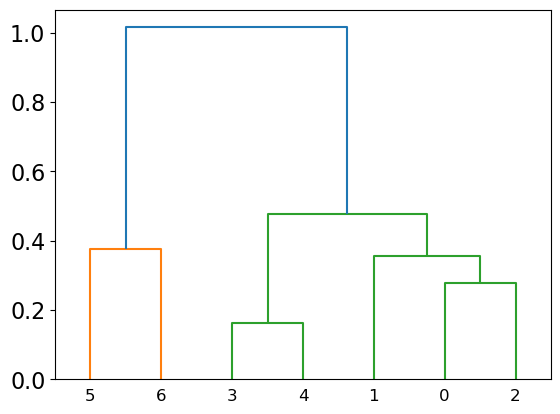

In [ ]:
import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn import preprocessing as pp 

a = np.loadtxt("Pdata11_11.txt")
b = pp.minmax_scale(a.T)  # 数据规格化(等比例变换，规则化变换)

distance = sch.distance.pdist(b)  # 求对象之间的距离，每行要是一个类，故数据规格化时转置，是对指标进行数据规则化
dd = sch.distance.squareform(distance)  # 转换为矩阵(n, n)
z = sch.linkage(distance, method='single')
T = sch.fcluster(z, 0.5)

print(dd)
print(z)  # 聚类显示
print(T)

s = [str(i) for i in range(7)]  # 与Z的行数对应

plt.rcParams['font.size'] = 16
sch.dendrogram(z, labels=s)  # 聚类树状图
plt.show()

各对象之间的最长距离矩阵为:
[[0.         0.35618248 0.27853564 0.68512552 0.6151268  1.14638279
  1.2662624 ]
 [0.35618248 0.         0.54290736 1.01397033 0.9625535  1.07229596
  1.10576035]
 [0.27853564 0.54290736 0.         0.48598717 0.47781458 1.01602914
  1.16879673]
 [0.68512552 1.01397033 0.48598717 0.         0.16258132 1.28318602
  1.50974389]
 [0.6151268  0.9625535  0.47781458 0.16258132 0.         1.34763954
  1.57203348]
 [1.14638279 1.07229596 1.01602914 1.28318602 1.34763954 0.
  0.37626539]
 [1.2662624  1.10576035 1.16879673 1.50974389 1.57203348 0.37626539
  0.        ]]
聚类结果为:
[[ 3.          4.          0.16258132  2.        ]
 [ 0.          2.          0.27853564  2.        ]
 [ 5.          6.          0.37626539  2.        ]
 [ 1.          8.          0.54290736  3.        ]
 [ 7.         10.          1.01397033  5.        ]
 [ 9.         11.          1.57203348  7.        ]]


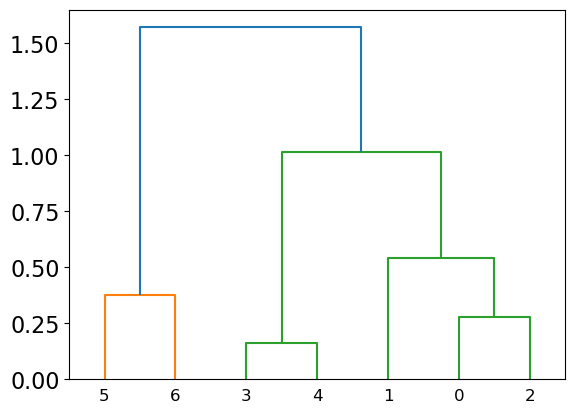

In [ ]:
from re import I
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing as pp
import scipy.cluster.hierarchy as sch

a = np.loadtxt("Pdata11_11.txt")  # (3, 7)
b = pp.minmax_scale(a.T)  # 保证sch.distance.pdist的参数每行是一类

d = sch.distance.pdist(b)  # 计算距离向量
dd = sch.distance.squareform(d)  # 转换成n阶矩阵
Z = sch.linkage(d, method='complete')  # 聚类结果

print(f"各对象之间的最长距离矩阵为:\n{dd}")
print(f"聚类结果为:\n{Z}")

label = [str(i) for i in range(7)]

plt.rcParams['font.size'] = 16
sch.dendrogram(Z, labels=label)
plt.show()

### 例 11.13  
已知聚类的指标变量为 $x_1, x_2$，四个样本点的数据分别为  
$$
\omega_1 = (1, 3),\quad \omega_2 = (1.5, 3.2),\quad \omega_3 = (1.3, 2.8),\quad \omega_4 = (3, 1).
$$  
试用 $K$ 均值聚类法把样本点分成两类.  


**解**  现要分为两类 $G_1$ 和 $G_2$，设初始聚类为 $G_1 = \{\omega_1\}$，$G_2 = \{\omega_2, \omega_3, \omega_4\}$，则初始聚类中心为  

- $G_1$ 类：$\omega_1$ 值，即 $\boldsymbol{m}_1 = (1, 3)$；  
- $G_2$ 类：  
$$
\boldsymbol{m}_2 = \left( \frac{1.5 + 1.3 + 3}{3},\, \frac{3.2 + 2.8 + 1}{3} \right) = (1.9333,\, 2.3333).
$$  


计算每个样本点到 $G_1, G_2$ 聚类中心的距离  

$$
\begin{align*}
d_{11} &= \|\omega_1 - \boldsymbol{m}_1\| = \sqrt{(1 - 1)^2 + (3 - 3)^2} = 0, & d_{12} &= \|\omega_1 - \boldsymbol{m}_2\| = 1.1470; \\
d_{21} &= \|\omega_2 - \boldsymbol{m}_1\| = 0.5385, & d_{22} &= \|\omega_2 - \boldsymbol{m}_2\| = 0.9690; \\
d_{31} &= \|\omega_3 - \boldsymbol{m}_1\| = 0.3606, & d_{32} &= \|\omega_3 - \boldsymbol{m}_2\| = 0.7867; \\
d_{41} &= \|\omega_4 - \boldsymbol{m}_1\| = 2.8284, & d_{42} &= \|\omega_4 - \boldsymbol{m}_2\| = 1.7075.
\end{align*}
$$  


得到新的划分为 $G_1 = \{\omega_1, \omega_2, \omega_3\}$，$G_2 = \{\omega_4\}$，新的聚类中心为  

- $G_1$ 类：  
$$
\boldsymbol{m}_1 = \left( \frac{1 + 1.5 + 1.3}{3},\, \frac{3 + 3.2 + 2.8}{3} \right) = (1.2667,\, 3.0);
$$  
- $G_2$ 类：$\omega_4$ 值，即 $\boldsymbol{m}_2 = (3, 1)$.  

重新计算每个样本点到 $G_1, G_2$ 聚类中心的距离  

$$
\begin{align*}
d_{11} &= \|\omega_1 - \boldsymbol{m}_1\| = 0.2667, & d_{12} &= \|\omega_1 - \boldsymbol{m}_2\| = 2.8284; \\
d_{21} &= \|\omega_2 - \boldsymbol{m}_1\| = 0.3073, & d_{22} &= \|\omega_2 - \boldsymbol{m}_2\| = 2.6627; \\
d_{31} &= \|\omega_3 - \boldsymbol{m}_1\| = 0.2028, & d_{32} &= \|\omega_3 - \boldsymbol{m}_2\| = 2.4759; \\
d_{41} &= \|\omega_4 - \boldsymbol{m}_1\| = 2.6466, & d_{42} &= \|\omega_4 - \boldsymbol{m}_2\| = 0.
\end{align*}
$$  


所以，得新的划分为：$G_1 = \{\omega_1, \omega_2, \omega_3\}$，$G_2 = \{\omega_4\}$.  

可见，新的划分与前面的划分相同，聚类中心没有改变，聚类结束.  


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import os

os.environ['PYTHONIOENCODING'] = 'utf-8'
os.environ['LOKY_MAX_CPU_COUNT'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

a = np.array([[1, 3], [1.5, 3.2], [1.3, 2.8], [3, 1]])

md = KMeans(n_clusters=2)  # 构建模型
md.fit(a)  # 求解模型

labels = 1 + md.labels_  # 提取聚类标签
centers = md.cluster_centers_  # 提取聚类中心，每一行是一个聚类中心

print(labels, '\n-----------\n', centers)

[1 1 1 2] 
-----------
 [[1.26666667 3.        ]
 [3.         1.        ]]


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### 1.簇内离差平方和拐点法

为了验证这个方法的直观性，这里随机生成三组二维正态分布数据，首先基千该数据绘制散点图如图 11.4(a) 所示，模拟的数据呈现三个簇．接下来基于这个模拟数据，使用拐点法，绘制簇的个数与总的簇内离差平方和之间的折线图如图 11.4(b)所示。

从图 11.4(b) 可以看出，当簇的个数为 3 时形成了一个明显的拐点， 3 之后的簇对应的簇内离差平方和的变动都很小，合理的 K值应该为 3，与模拟的三个簇数据是吻合的


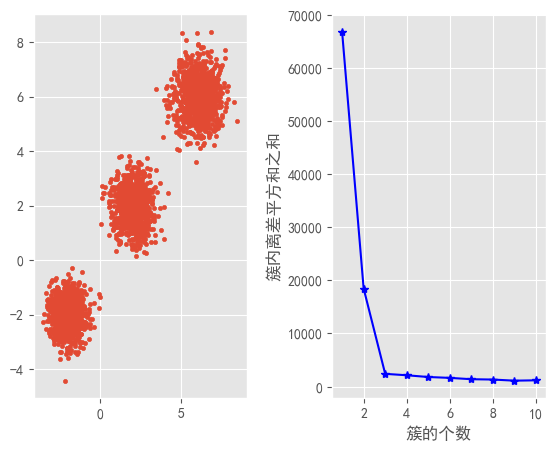

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
# 二维高斯(正态)分布，故用(3, 2)不用(3, 1) E(X)=E(Y)=number
mean = np.array([[-2, -2], [2, 2], [6, 6]])
# 三个正态分布的协方差矩阵,每次cov[i]取出一个协方差矩阵，帮助创建随机数
cov = np.array([[[0.3, 0], [0, 0.3]], [[0.4, 0], [0, 0.4]], [[0.5, 0], [0, 0.5]]])
x0 = []
y0 = []

for i in range(3):
    # 生成(1000, 2)的数据，再拆包得到x, y
    x, y = np.random.multivariate_normal(mean[i], cov[i], 1000).T
    x0 = np.hstack([x0, x])  # 循环结束(3000,)
    y0 = np.hstack([y0, y])  # 循环结束(3000,)

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

plt.subplot(1, 2, 1)
plt.scatter(x0, y0, marker='.')  # 画模拟数据点的散点图
X = np.vstack([x0, y0]).T  # vstack垂直连接后(2, 3000),转置后(3000, 2)
np.savetxt("二维正态数据.txt", X)

# sum of squared deviations 离差平方和
TSSE = []  # Total Sum of Square Error总平方和误差
K = 10  # 最多簇=10

for k in range(1, K+1):  # 计算每簇的总平方和误差
    SSE = []  # Sum of Square Error
    md = KMeans(n_clusters=k)  # model=md
    md.fit(X)
    labels = md.labels_  # (3000,)，labels[i]=k(0~9)  ⇔  第 i 行样本被分到第 k 个簇
    centers = md.cluster_centers_  # 聚类中心，(k, 2),每一行一个聚类中心(质心)
    for label in set(labels):  # set(labels)={0, 1, 2, 3, 4, 5, 6, 7, 8, 9},集合无重复元素取出所有的簇号
        SSE.append(np.sum((X[labels == label, :] - centers[label, :]) ** 2))  # 计算离差平方和,列表
    TSSE.append(np.sum(SSE))  # 最终为列表，10个元素

plt.subplot(1, 2, 2)
plt.style.use('ggplot')
plt.plot(range(1, K+1), TSSE, 'b*-')
plt.xlabel('簇的个数')
plt.ylabel('簇内离差平方和之和')
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, hspace=0.4, wspace=0.4)  # 调整子图
plt.show()

#### 2. 轮廓系数法(轮廓系数越大越好)

`sklearn.metrics` 中的函数 `silhouette_ score`(轮廓系数). 需要注意的是，该函数接受的聚类簇数必须大于等于 2.

利用上面同样的模拟数据， 画出的簇数与轮廓系数对应关系图如图 11.6 所示，当 k 等于 3 时轮廓系数最大， 且比较接近千 1，说明应该把模拟数据聚为 3 类比较合理， 同样与模拟数据的三个簇是吻合的

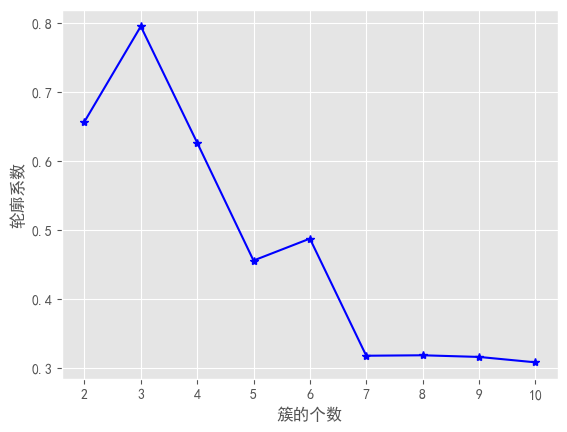

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import metrics
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
X = np.loadtxt("二维正态数据.txt")
S = []
K = 10
for k in range(2, K+1):
    md = KMeans(n_clusters=k)
    md.fit(X)
    # 计算轮廓系数
    labels = md.labels_
    S.append(metrics.silhouette_score(X, labels, metric='euclidean'))

plt.rcParams['font.family'] = 'SimHei'
plt.plot(range(2, K+1), S, 'b*-')
plt.xlabel('簇的个数')
plt.ylabel('轮廓系数')
plt.show()

Iris 数据集是常用的分类实验数据集,下面用该数据集来验证 $K$ 均值聚类的效果.

例 11.14 Iris 数据集由 Fisher 于 1936 年收集整理. Iris 也称鸢尾花卉数据,是一类多重变量分析的数据集. 数据集包含 150 个数据,分为 3 类,每类 50 个数据,每个数据包含 4 个属性,数据格式如表 11.12 所示. 可通过花萼长度、花萼宽度、花瓣长度、花瓣宽度 4 个属性预测鸢尾花卉属于 (setosa, versicolour, virginica) 三个种类中的哪一类.

表 11.12 Iris 数据集数据

|        | Sepal_Length | Sepal_Width | Petal_Length | Petal_Width | Species   |
| ------ | ------------ | ----------- | ------------ | ----------- | --------- |
| 1      | 5.1          | 3.5         | 1.4          | 0.2         | setosa    |
| 2      | 4.9          | 3           | 1.4          | 0.2         | setosa    |
| $\vdots$ | $\vdots$      | $\vdots$     | $\vdots$      | $\vdots$     | $\vdots$   |
| 149    | 6.2          | 3.4         | 5.4          | 2.3         | virginica |
| 150    | 5.9          | 3           | 5.1          | 1.8         | virginica |

注: 全部数据见数据文件 iris.csv (数据见封底二维码)

如表 11.12 所示,数据集的前 4 个变量分别为花萼的长度、宽度及花瓣的长度、宽度,它们之间没有量纲上的差异,故无需对其做标准化预处理,最后一个变量为鸢尾花所属的种类. 如果将其聚为 3 类,所得结果为各簇样本量分别为 60, 50, 38. 为了直观验证聚类效果,对比建模后的 3 类与原始数据 3 类的差异,绘制花瓣长度与宽度的散点图如图 11.7 所示.

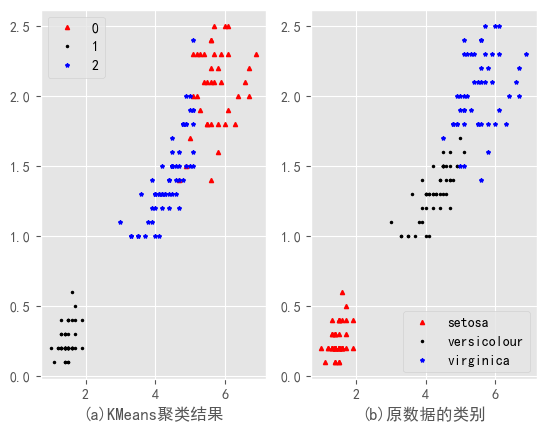

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("iris.csv")
df_no_label = df.iloc[:, :-1]

md = KMeans(n_clusters=3)
md.fit(df_no_label)

labels = md.labels_
centers = md.cluster_centers_
df_no_label['cluster'] = labels  # 增加一列cluster

frequency = df_no_label.cluster.value_counts()  # 各类频数统计

plt.rcParams['font.family'] = 'SimHei'
str1 = ['^r', '.k', '*b']

plt.subplot(121)
for i in range(len(centers)):
    plt.plot(df_no_label['Petal_Length'][labels==i], df_no_label['Petal_Width'][labels==i], str1[i], markersize=3, label=str(i))
    plt.legend()
    plt.xlabel("(a)KMeans聚类结果")

plt.subplot(122)
str2 = ['setosa', 'versicolour', 'virginica']
ind = np.hstack([np.zeros(50), np.ones(50), 2*np.ones(50)])
for i in range(3):
    plt.plot(df_no_label['Petal_Length'][ind==i], df_no_label['Petal_Width'][ind==i], str1[i], markersize=3, label=str2[i])
    plt.legend(loc='lower right')
    plt.xlabel("(b)原数据的类别")
plt.show()

In [57]:
df_no_label

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0
